# Trainning

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from imblearn.metrics import geometric_mean_score

df = pd.read_csv("Banjir all - Data Acak (1).csv")

print("Data awal:")
print(df.head())

# Hapus kolom yang tidak akan dipakai sebagai fitur prediksi
df = df.drop(columns=['Tanggal', 'Tinggi Banjir', 'Banjir Ya/Tidak'], errors='ignore')

# Dataset memiliki karakter '-' untuk data kosong, kita ubah ke NaN
df = df.replace('-', np.nan)

# Pastikan kolom numerik memiliki tipe data float
kolom_numerik = ['Curah Hujan', 'Debit Air', 'Muka Air']
for col in kolom_numerik:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Isi missing value dengan forward fill lalu backward fill
df = df.ffill().bfill()

In [ ]:
def tentukan_level_banjir(tma):
    """
    Menentukan level banjir berdasarkan Tinggi Muka Air (TMA).
    Threshold berdasarkan referensi:
    - Normal  : < 0.57 meter (termasuk 0.20 - 0.57)
    - Waspada : 0.57 - 0.93 meter
    - Siaga   : 0.93 - 1.30 meter
    - Awas    : > 1.30 meter
    """
    if tma < 0.57:
        return '0 - Normal'
    elif 0.57 <= tma < 0.93:
        return '1 - Waspada (Siaga 3)'
    elif 0.93 <= tma <= 1.30:
        return '2 - Siaga (Siaga 2)'
    else:
      return '3 - Awas (Siaga 1)'

# Aplikasikan fungsi ke kolom Muka Air untuk membuat target baru
df['Level_Banjir'] = df['Muka Air'].apply(tentukan_level_banjir)

print("\nDistribusi Level Banjir:")
print(df['Level_Banjir'].value_counts())
label_encoders = {}

# Encode fitur kategorik (misal: Kecamatan)
for col in df.columns:
    if df[col].dtype == 'object' and col != 'Level_Banjir':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        label_encoders[col] = le

# Encode Target (Level Banjir)
le_target = LabelEncoder()
df['Level_Banjir'] = le_target.fit_transform(df['Level_Banjir'])
X = df.drop(columns=['Level_Banjir'])
y = df['Level_Banjir']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Gunakan mlogloss untuk klasifikasi lebih dari 2 kelas (Multiclass)
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Data awal:
     Kecamatan     Tanggal Curah Hujan Debit Air Muka Air Tinggi Banjir  \
0  Dayeuhkolot  2020-01-01        48.0     90.75     5.16             -   
1  Dayeuhkolot  2020-01-02         0.0     70.82     4.52             -   
2  Dayeuhkolot  2020-01-03           -     60.22     4.13             -   
3  Dayeuhkolot  2020-01-04         0.0     55.49     3.94             -   
4  Dayeuhkolot  2020-01-05         0.0     53.03     3.84             -   

   Banjir Ya/Tidak  
0              0.0  
1              0.0  
2              0.0  
3              0.0  
4              0.0  

Distribusi Level Banjir:
Level_Banjir
3 - Awas (Siaga 1)       2884
0 - Normal                188
2 - Siaga (Siaga 2)       112
1 - Waspada (Siaga 3)      96
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:58:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Akurasi:
0.9969512195121951

Classification Report:
                       precision    recall  f1-score   support

           0 - Normal       1.00      1.00      1.00        37
1 - Waspada (Siaga 3)       0.95      1.00      0.98        20
  2 - Siaga (Siaga 2)       1.00      0.93      0.96        28
   3 - Awas (Siaga 1)       1.00      1.00      1.00       571

             accuracy                           1.00       656
            macro avg       0.99      0.98      0.98       656
         weighted avg       1.00      1.00      1.00       656


G-Mean Score:
0.9894


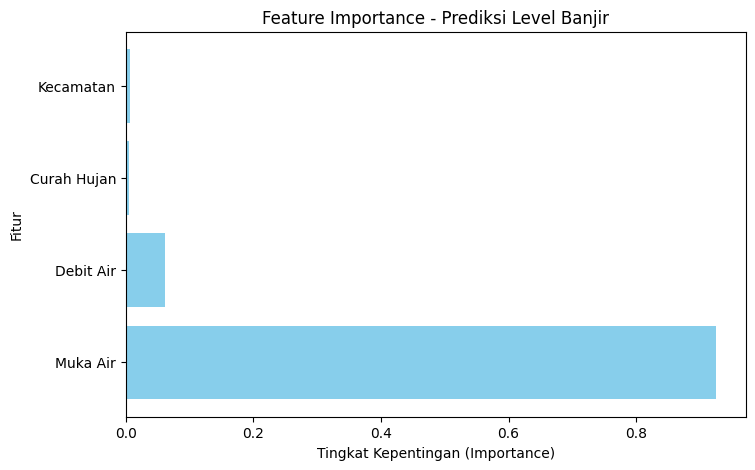

In [ ]:
print("\nAkurasi:")
print(accuracy_score(y_test, y_pred))

print("\nClassification Report:")
# Tampilkan nama kelas asli dari Label Encoder target
nama_kelas = [str(kelas) for kelas in le_target.classes_]
print(classification_report(y_test, y_pred, target_names=nama_kelas))

# --- TAMBAHAN PERHITUNGAN G-MEAN ---
print("\nG-Mean Score:")
# Menggunakan average='macro' karena ini adalah masalah klasifikasi multiclass (4 kelas)
g_mean = geometric_mean_score(y_test, y_pred, average='macro')
print(f"{g_mean:.4f}")
# -----------------------------------

importance = model.feature_importances_
features = X.columns

plt.figure(figsize=(8, 5))
plt.barh(features, importance, color='skyblue')
plt.xlabel("Tingkat Kepentingan (Importance)")
plt.ylabel("Fitur")
plt.title("Feature Importance - Prediksi Level Banjir")
plt.gca().invert_yaxis() # Membalik urutan agar yang paling penting di atas (jika sudah disortir)
plt.show()

# Validation

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from imblearn.metrics import geometric_mean_score
df_train = pd.read_csv("Banjir all - Data Acak (1).csv")

df_train = df_train.drop(columns=['Tanggal', 'Tinggi Banjir', 'Banjir Ya/Tidak'], errors='ignore')
df_train = df_train.replace('-', np.nan)

kolom_numerik = ['Curah Hujan', 'Debit Air', 'Muka Air']
for col in kolom_numerik:
    if col in df_train.columns:
        df_train[col] = pd.to_numeric(df_train[col], errors='coerce')

df_train = df_train.ffill().bfill()

In [ ]:
def tentukan_level_banjir(tma):
    if tma < 0.57:
        return '0 - Normal'
    elif 0.57 <= tma < 0.93:
        return '1 - Waspada (Siaga 3)'
    elif 0.93 <= tma <= 1.30:
        return '2 - Siaga (Siaga 2)'
    else:
        return '3 - Awas (Siaga 1)'

df_train['Level_Banjir'] = df_train['Muka Air'].apply(tentukan_level_banjir)

# Simpan encoder agar bisa digunakan lagi di data validasi
label_encoders = {}
for col in df_train.columns:
    if df_train[col].dtype == 'object' and col != 'Level_Banjir':
        le = LabelEncoder()
        df_train[col] = le.fit_transform(df_train[col])
        label_encoders[col] = le

le_target = LabelEncoder()
df_train['Level_Banjir'] = le_target.fit_transform(df_train['Level_Banjir'])

X_train = df_train.drop(columns=['Level_Banjir'])
y_train = df_train['Level_Banjir']

# 2. TRAIN MODEL XGBOOST
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    # use_label_encoder=False, -> Baris ini dihapus agar tidak muncul warning
    eval_metric='mlogloss'
)
# Latih model menggunakan 100% data awal
model.fit(X_train, y_train)

# 3. LOAD & CLEAN DATA VALIDASI (BARU)
df_val = pd.read_csv("Banjir all - Data Vlidasi.csv")

# Lakukan pembersihan yang SAMA PERSIS dengan data training
df_val = df_val.drop(columns=['Tanggal', 'Tinggi Banjir', 'Banjir Ya/Tidak'], errors='ignore')
df_val = df_val.replace('-', np.nan)

for col in kolom_numerik:
    if col in df_val.columns:
        df_val[col] = pd.to_numeric(df_val[col], errors='coerce')

df_val = df_val.ffill().bfill()
df_val['Level_Banjir'] = df_val['Muka Air'].apply(tentukan_level_banjir)

# Encoding data validasi menggunakan encoder dari data training
for col in df_val.columns:
    if df_val[col].dtype == 'object' and col != 'Level_Banjir':
        if col in label_encoders:
            le = label_encoders[col]
            # Jika ada kategori baru (misal kecamatan baru) yg tidak ada di data latih, ubah ke -1
            df_val[col] = df_val[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)

# Encode target validasi
df_val['Level_Banjir'] = le_target.transform(df_val['Level_Banjir'])

X_val = df_val.drop(columns=['Level_Banjir'])
y_val = df_val['Level_Banjir']

  EVALUASI MODEL PADA DATA VALIDASI BARU 

Akurasi Keseluruhan:
1.0000

Classification Report:
                       precision    recall  f1-score   support

           0 - Normal       1.00      1.00      1.00        35
1 - Waspada (Siaga 3)       0.00      0.00      0.00         0
  2 - Siaga (Siaga 2)       1.00      1.00      1.00         2
   3 - Awas (Siaga 1)       1.00      1.00      1.00       537

             accuracy                           1.00       574
            macro avg       0.75      0.75      0.75       574
         weighted avg       1.00      1.00      1.00       574

G-Mean Score:
1.0000


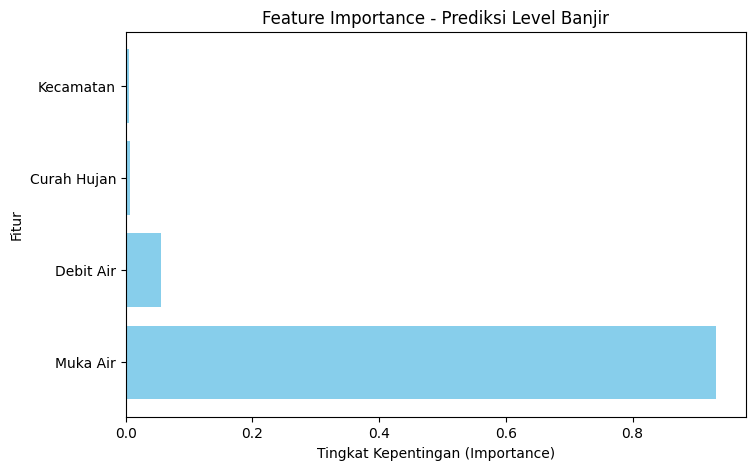

In [ ]:
# 4. PREDIKSI & EVALUASI PADA DATA VALIDASI
y_val_pred = model.predict(X_val)

print("=========================================")
print("  EVALUASI MODEL PADA DATA VALIDASI BARU ")
print("=========================================\n")

print("Akurasi Keseluruhan:")
print(f"{accuracy_score(y_val, y_val_pred):.4f}")

print("\nClassification Report:")
nama_kelas = [str(kelas) for kelas in le_target.classes_]
# --- PERBAIKAN DI SINI ---
# Tambahkan labels dan zero_division agar tidak error jika ada kelas yang absen di data validasi
print(classification_report(y_val, y_val_pred,
                            labels=range(len(nama_kelas)),
                            target_names=nama_kelas,
                            zero_division=0))

print("G-Mean Score:")
# Tambahkan error handling karena G-Mean juga bisa error jika kelasnya tidak lengkap
try:
    g_mean = geometric_mean_score(y_val, y_val_pred, average='macro')
    print(f"{g_mean:.4f}")
except ValueError:
    print("G-Mean tidak dapat dihitung dengan sempurna karena tidak semua level banjir (4 kelas) muncul di data validasi.")

# 5. FEATURE IMPORTANCE (Berdasarkan pembelajaran di data awal)
importance = model.feature_importances_
features = X_train.columns

plt.figure(figsize=(8, 5))
plt.barh(features, importance, color='skyblue')
plt.xlabel("Tingkat Kepentingan (Importance)")
plt.ylabel("Fitur")
plt.title("Feature Importance - Prediksi Level Banjir")
plt.gca().invert_yaxis()
plt.show()